# Spatial analysis for 10x Visium dataset
### Biological question: Does the lymph node's RNA-level biology (cell-type signatures, marker genes, differential gene expression) organize into coherent physical regions in the tissue, or is it spatially random — and which genes/cell types define those regions?


In [1]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt


# plot visual settings
sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor="white")

/Users/yukamurakami/miniconda3/envs/element-prep/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/Users/yukamurakami/miniconda3/envs/element-prep/lib/python3.11/site-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [2]:
adata = sq.datasets.visium("V1_Human_Lymph_Node")
adata

/Users/yukamurakami/miniconda3/envs/element-prep/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/yukamurakami/miniconda3/envs/element-prep/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 4035 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

4035 spots (~55um in diameter, 1-10+ cells), 36601 genes

### What is included in the adata object?
- obs is a pandas df with 3 columns. is the spot in the tissue or background? array_row and array_col show a spot's location on the Visium grid (spatial does this too, but it does it as sample-specific coordinates) obs describes each spot themselves
- var is a pandas df with 3 columns. what's the Ensembl gene ID? gene expression? reference genome used to map each gene?
- uns means unstructured. it's a dict that holds the H&E-stained microscope image
- obsm is a dict-like container where each entry is a np array that defines something about each spot in obs. holds spatial, which contains sample-specific coordinates of the spot in the tissue. It's called matrix because it stores matrices. 

## QC

### Investigating the dataset, dropping spots with little transcripts, and genes with little expression in spots

Observe X, the gene expression profile. Let's check that the values are raw, and see the max.

In [3]:
# what's the data type of X
print(adata.X.dtype)

# show the array converting from sparse
print(adata.X[:10, :10].toarray())

# show the max value in the expression data
adata.X.max()

float32
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


np.float32(8745.0)

In [4]:
# how many spots are actually in tissue?
print("how many spots are actually in tissue?\n", adata.obs['in_tissue'].value_counts())

# drop spots not in tissue (they've been pre-filtered)
adata = adata[adata.obs['in_tissue'] == 1].copy()

# how many do we have left?
print(adata.shape)

how many spots are actually in tissue?
 in_tissue
1    4035
Name: count, dtype: int64
(4035, 36601)


/Users/yukamurakami/miniconda3/envs/element-prep/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Flag the mt genes and add some new cols to obs to be used for QC.

In [5]:
# Flag mitochondrial genes and put it into a new col in var 
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print(adata.var["mt"].sum(), "mitochondrial genes found")

# gene names have duplicates sometimes 
print(adata.var_names.duplicated().sum())
adata.var_names_make_unique()

# use scanpy preprocessing to add cols to obs
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt"], inplace=True, percent_top=None, log1p=False
)

# look at general metrics for these qc categories 
adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe()

13 mitochondrial genes found
10


,total_counts,n_genes_by_counts,pct_counts_mt
count,4035.000000,4035.000000,4035.000000
mean,20737.724609,5877.845353,1.209016
std,7160.780762,1166.414288,0.679819
min,23.000000,23.000000,0.000000
25%,15917.000000,5254.000000,0.875451
50%,20239.000000,5999.000000,0.989313
75%,25251.500000,6641.500000,1.197335
max,54931.000000,9168.000000,5.410122


On average, a spot expresses about 20k rna transcripts (total_counts),  from about 5.8k genes (n_genes_by_counts), and about 1.2% of those counts come from mt genes. It's easier to visualize this before deciding cutoffs. 

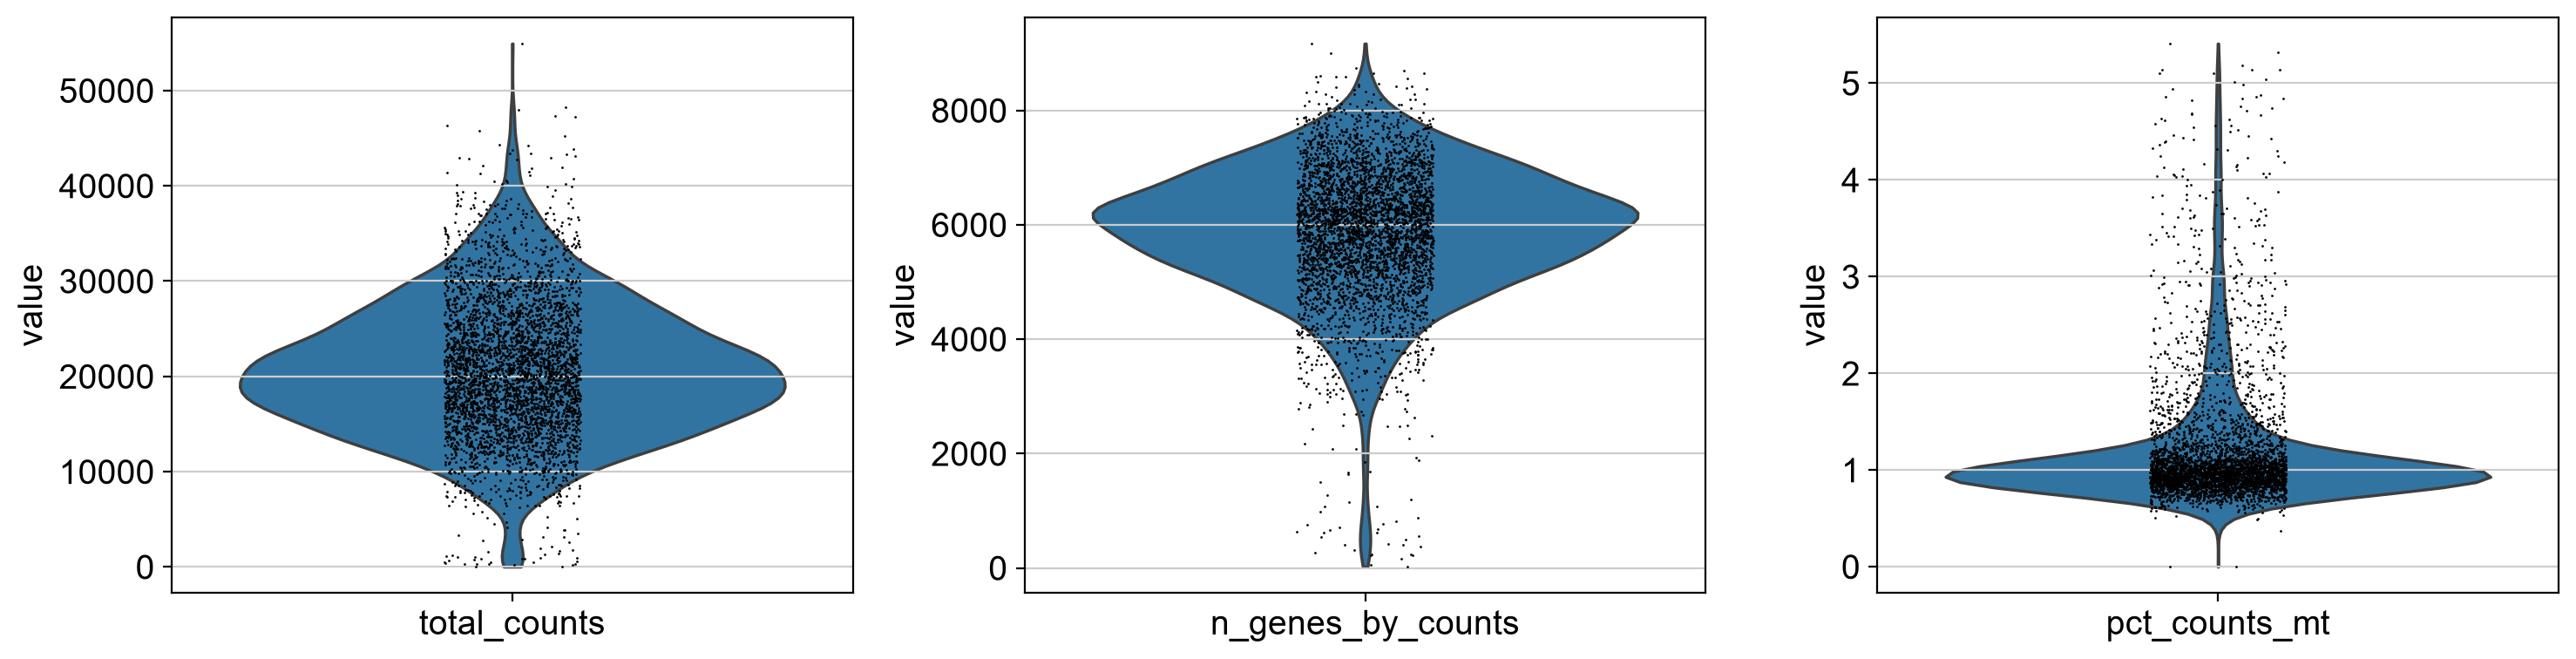

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sc.pl.violin(adata, "total_counts", ax=axs[0], show=False)
sc.pl.violin(adata, "n_genes_by_counts", ax=axs[1], show=False)
sc.pl.violin(adata, "pct_counts_mt", ax=axs[2], show=False)
plt.tight_layout()
plt.show()

From the violin plots, we can gather that most spots have ~20k transcripts, but some are very low (0), and very little are very high (50k). Most transcripts are from about 6k genes, but few are from less than that. Most transcripts have 1% mtrna, although many are higher.

In [7]:
adata.obs['total_counts'].sort_values().head(20)
# adata.obs['n_genes_by_counts'].sort_values().head(20)

ACTGTAGCACTTTGGA-1     23.0
CCCGCCATGCTCCCGT-1     51.0
CCGCGCAAGATACCCA-1    186.0
AGAAGAGCGCCGTTCC-1    253.0
GTCTCCTGCCAGTATG-1    261.0
TCAGCTTGAGCTTTCG-1    301.0
CAGTAAGGGACGTCTC-1    302.0
TCGTGTACTATGGATG-1    331.0
ATGCACGCGCTGTTCA-1    383.0
TCGCGTAGCAGTGTCC-1    465.0
CCTATATCGTGTCACG-1    505.0
GCCTTTGTCAGTGGAC-1    510.0
ATATAGAGTATTGGTC-1    540.0
AAACTTAATTGCACGC-1    642.0
ACCGTCCACTGGGCCC-1    780.0
TCCATCAATACTAATC-1    819.0
CTATACTTAAAGCGAG-1    830.0
AATTCATTGTCATGCA-1    886.0
TAGTACCACAACTTTC-1    904.0
CTCGCATTGCATAGCC-1    923.0
Name: total_counts, dtype: float32

Looking at the head(20) doesn't show us the cutoff, so let's make a knee plot to find the cutoff. 

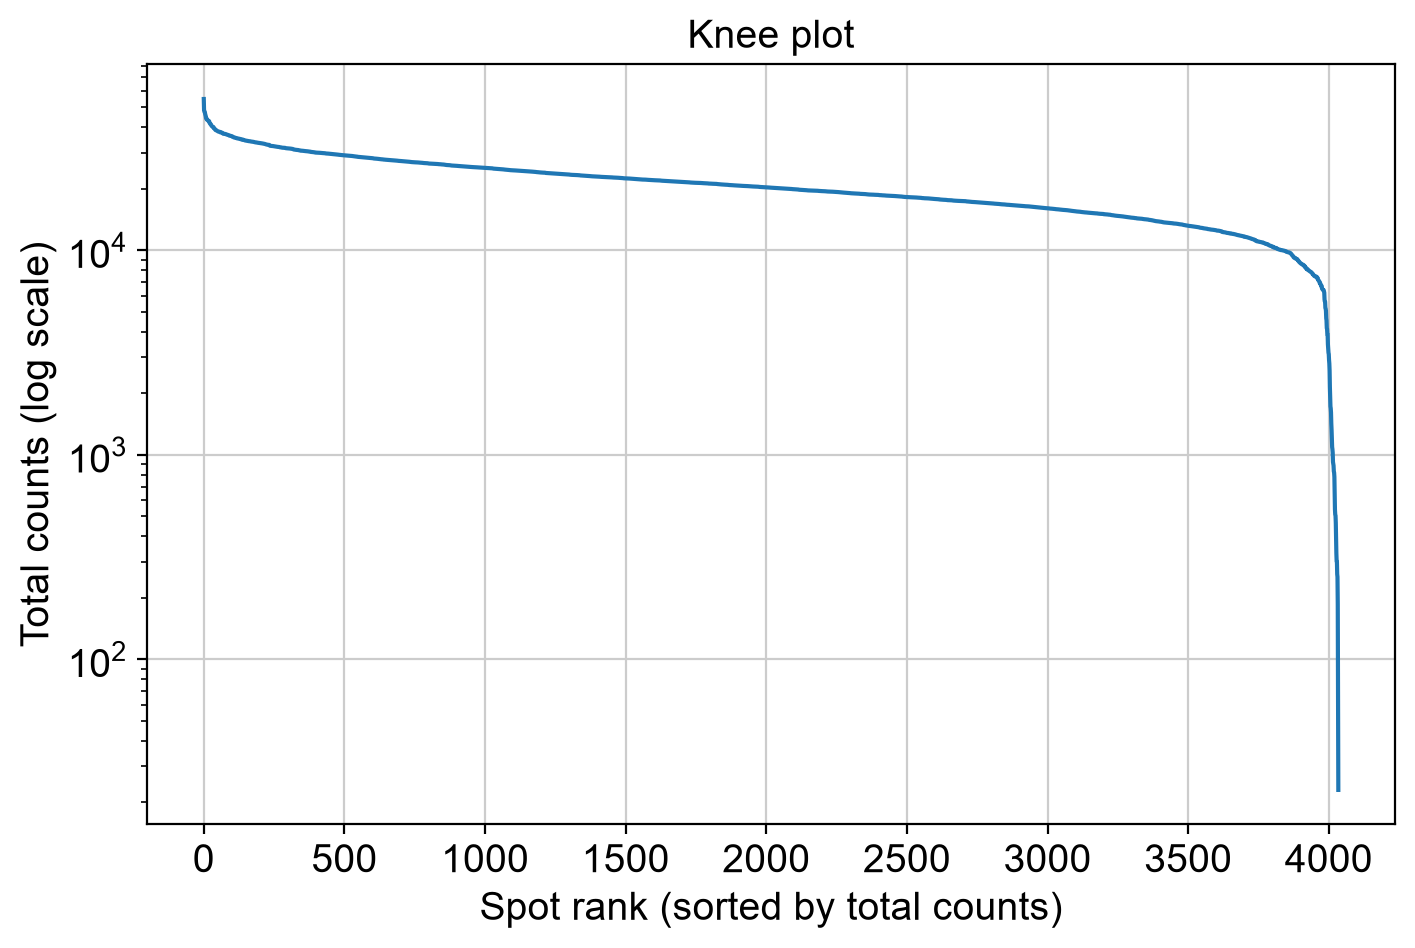

In [8]:
# sort big to small
sorted_counts = adata.obs['total_counts'].sort_values(ascending=False).values

plt.figure(figsize=(8, 5))
plt.plot(range(len(sorted_counts)), sorted_counts)
plt.yscale('log')
plt.xlabel('Spot rank (sorted by total counts)')
plt.ylabel('Total counts (log scale)')
plt.title('Knee plot')
plt.show()

We can also look at where the biggest jump is using .diff()! We can work with 4000, as the cutoff occurs there. Let's filter using .filter_cells()!  

In [9]:
sc.pp.filter_cells(adata, min_counts=4000)
print(adata.shape)

(3995, 36601)


Went from 4035 to 3995 spots, dropping only ~40, keeping most of the data. 

In [10]:
sc.pp.filter_genes(adata, min_cells=3)
print(adata.shape)

(3995, 22407)


Dropped genes that were in barely any spots, these genes are "undetected". 

In [11]:
adata.obs['pct_counts_mt'].sort_values(ascending=False).head(10)

GCATACGAGGTCTTTA-1    5.410122
ACGCTGTGAGGCGTAG-1    5.315581
AAACCTCATGAAGTTG-1    5.141419
AATCTCTACTGTGGTT-1    5.137166
CCTGTACTCACGCCCA-1    5.136322
TACTCGGCACGCCGGG-1    5.107842
AGAGATCTCTAAAGCG-1    5.102734
ACTTTGACTGCATCCT-1    5.036611
AGGTGTATCGCCATGA-1    5.015517
CCCTGACTAACAAATT-1    4.987756
Name: pct_counts_mt, dtype: float32

Mitochondrial percentage was uniformly low across spots (max 5.4%), so no additional mito-based filtering was applied beyond the count threshold

## Normalization

We make a copy of the expression matrix just in case we need it later. Then we normalize, so that all spots are being read on the same playing field. The expression of a gene in a spot is measured by the ratio of the raw count to total expression of that spot. (raw count / total counts) x 10000. The target sum is just to make the number readable and not a tiny decimal. We also log transform so that large expression values don't dominate. 

In [12]:
# Save raw counts before normalizing, in case you need them later (e.g. for certain squidpy functions that expect raw counts)
# we're making a copy of X in a new storage in adata
adata.layers["counts"] = adata.X.copy()

# Normalize total counts per spot to the same value, 10,000
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform
sc.pp.log1p(adata)

adata.X.max()  # should now be a much smaller number, not tens of thousands

np.float32(7.608652)

In [13]:
adata.layers["counts"].max()  # should still show your original raw max

np.float32(8745.0)

If we look at X's max, its around 7, which is a small number compared to the raw counts. If we look at the copy we made, counts, the max shows the original raw 8745.

## Highly Variable Genes and PCA
We're flagging the 2000 genes with the most informative information across spots. These are genes where a spot may have more expression compared to another spot. This reduces noise and computation for PCA by focusing on genes that actually differ meaningfully. 

In [14]:
# hvg
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)
print(adata.var["highly_variable"].sum())

# pca with 50 components, finds 50 most varying directions 
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)

# make neighbors graph 
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

2000


/Users/yukamurakami/miniconda3/envs/element-prep/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


PCA with 50 components

In [15]:
sc.pp.pca(adata, n_comps=50, use_highly_variable=True)

/Users/yukamurakami/miniconda3/envs/element-prep/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Use those 50 components and each spot's location along those dimensions to make a neighbors graph. It finds the closest 15 neighbors for each spot based on the 50 pcs but the result is a sparse matrix of each spot to their closest neighbors and their distance/connectivites. These are stored in adata.obsp['distances'] and adata.obsp['connectivites'].

In [16]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=50)

Now we do clustering on the neighborhood graph (we now know each spot's closest neighbors so we can group them into clusters). Leiden results in a pandas df that shows a category for each spot. 

In [ ]:
sc.tl.leiden(adata, resolution=1.0) # higher resolution means more clusters, we don't control k clusters but we do control this
print(adata.obs["leiden"].value_counts())

/var/folders/gv/gbf3xv4d3hl0xccvbw6j48_m0000gn/T/ipykernel_1439/34369498.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=1.0)


leiden
0    707
1    551
2    452
3    437
4    421
5    419
6    407
7    307
8    172
9    122
Name: count, dtype: int64


In [ ]:
# shows each spot's assigned cluster
adata.obs['leiden'].head()

AAACAAGTATCTCCCA-1    1
AAACAATCTACTAGCA-1    3
AAACACCAATAACTGC-1    2
AAACAGAGCGACTCCT-1    9
AAACAGCTTTCAGAAG-1    4
Name: leiden, dtype: category
Categories (10, object): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

UMAP is useful to see how clusters are distributed. UMAP squashes 50pcs into 2D so we can visualize them. 

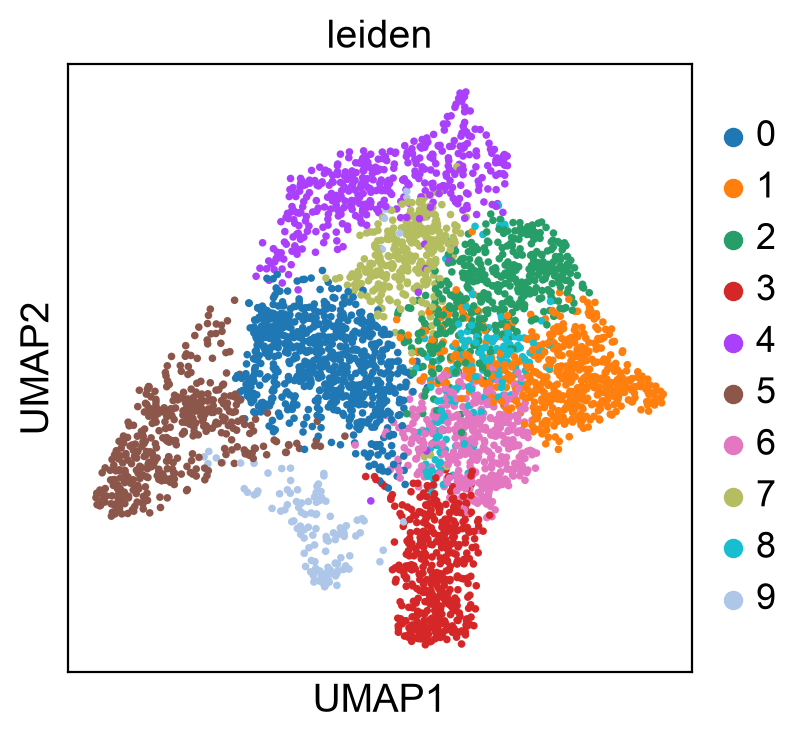

In [19]:
sc.tl.umap(adata)
sc.pl.umap(adata, color="leiden")

Now we use .spatial to visualize it in terms of the tissue. 

/var/folders/gv/gbf3xv4d3hl0xccvbw6j48_m0000gn/T/ipykernel_1439/1288300054.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="leiden", size=1.5)


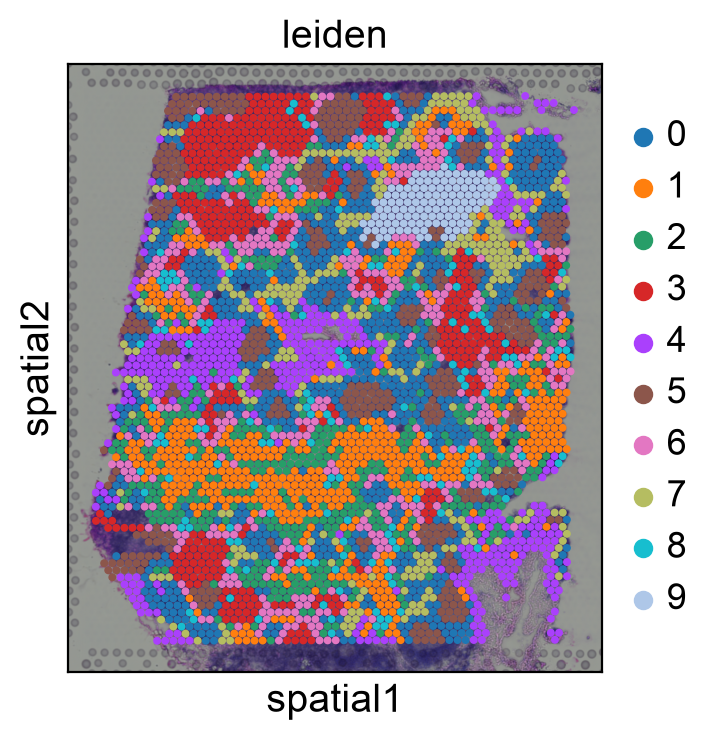

In [20]:
sc.pl.spatial(adata, color="leiden", size=1.5)

This shows grouping of different cell zones in oval regions/patches. Not super random or scattered, pretty organized. Being able to visualize this spatially is valuable compared to scRNA-seq data because you can see where in the tissue the transcription is coming from.

This is plotting using the 9 clusters, but if we use marker genes that represent T-cells, B-cells, and macrophages, we can understand better which types of cells exist in which locations of the tissue. I'm noticing that cluster 3 corresponds to the CD3E gene and represents the T-cells. I'm noticing a connection between cluster 0 and B-cells. Macrophages are not standing out very much but may be correlated to cluster 9, the signal is not strong.

/var/folders/gv/gbf3xv4d3hl0xccvbw6j48_m0000gn/T/ipykernel_1439/3910472126.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["CD3E", "CD19", "CD68"], size=1.5)


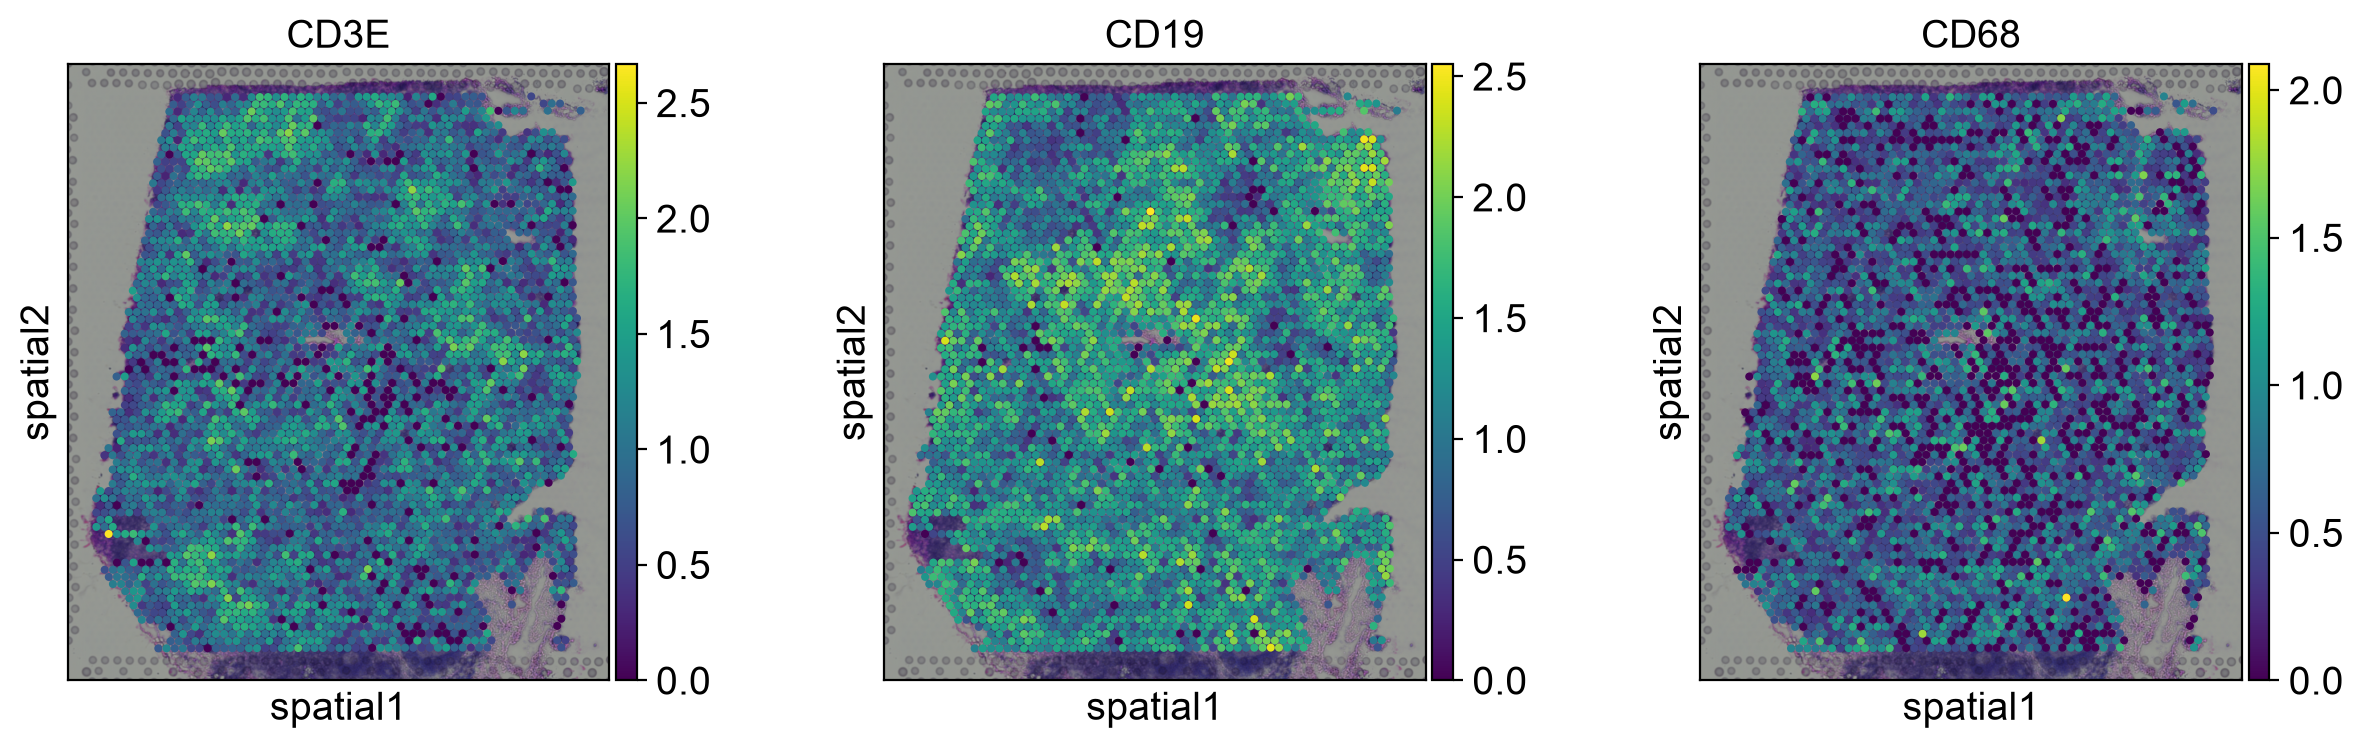

In [21]:
sc.pl.spatial(adata, color=["CD3E", "CD19", "CD68"], size=1.5)

I knew to look for these genes because they are known marker genes for those immune cell types. But there are other genes that may uncover spatial information that we're not aware of. We use spatial neighbors to find genes in physical neighbors that are highly variable. 

In [24]:
sq.gr.spatial_neighbors(adata)
sq.gr.spatial_autocorr(adata, mode="moran")
adata.uns["moranI"].head(10)


INFO     Creating graph using `None` transform and `1` libraries.                                                  


/var/folders/gv/gbf3xv4d3hl0xccvbw6j48_m0000gn/T/ipykernel_1439/3357270649.py:1: FutureWarning: Calling `spatial_neighbors` is deprecated and will be removed in squidpy v1.9.0. Use `spatial_neighbors_knn`, `spatial_neighbors_radius`, `spatial_neighbors_delaunay`, `spatial_neighbors_grid`, or `spatial_neighbors_from_builder` instead.
  sq.gr.spatial_neighbors(adata)


,I,pval_norm,var_norm,pval_norm_fdr_bh
IGKC,0.748120,0.0,0.000088,0.0
IGHG4,0.747180,0.0,0.000088,0.0
IGHG1,0.744030,0.0,0.000088,0.0
CCL21,0.730788,0.0,0.000088,0.0
FDCSP,0.716808,0.0,0.000088,0.0
MT-CO1,0.665110,0.0,0.000088,0.0
IGHG2,0.661083,0.0,0.000088,0.0
TMSB4X,0.654027,0.0,0.000088,0.0
MT-CO3,0.632221,0.0,0.000088,0.0
MT-CO2,0.619216,0.0,0.000088,0.0


/var/folders/gv/gbf3xv4d3hl0xccvbw6j48_m0000gn/T/ipykernel_1439/2468516712.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=top_genes, size=1.5, ncols=3)


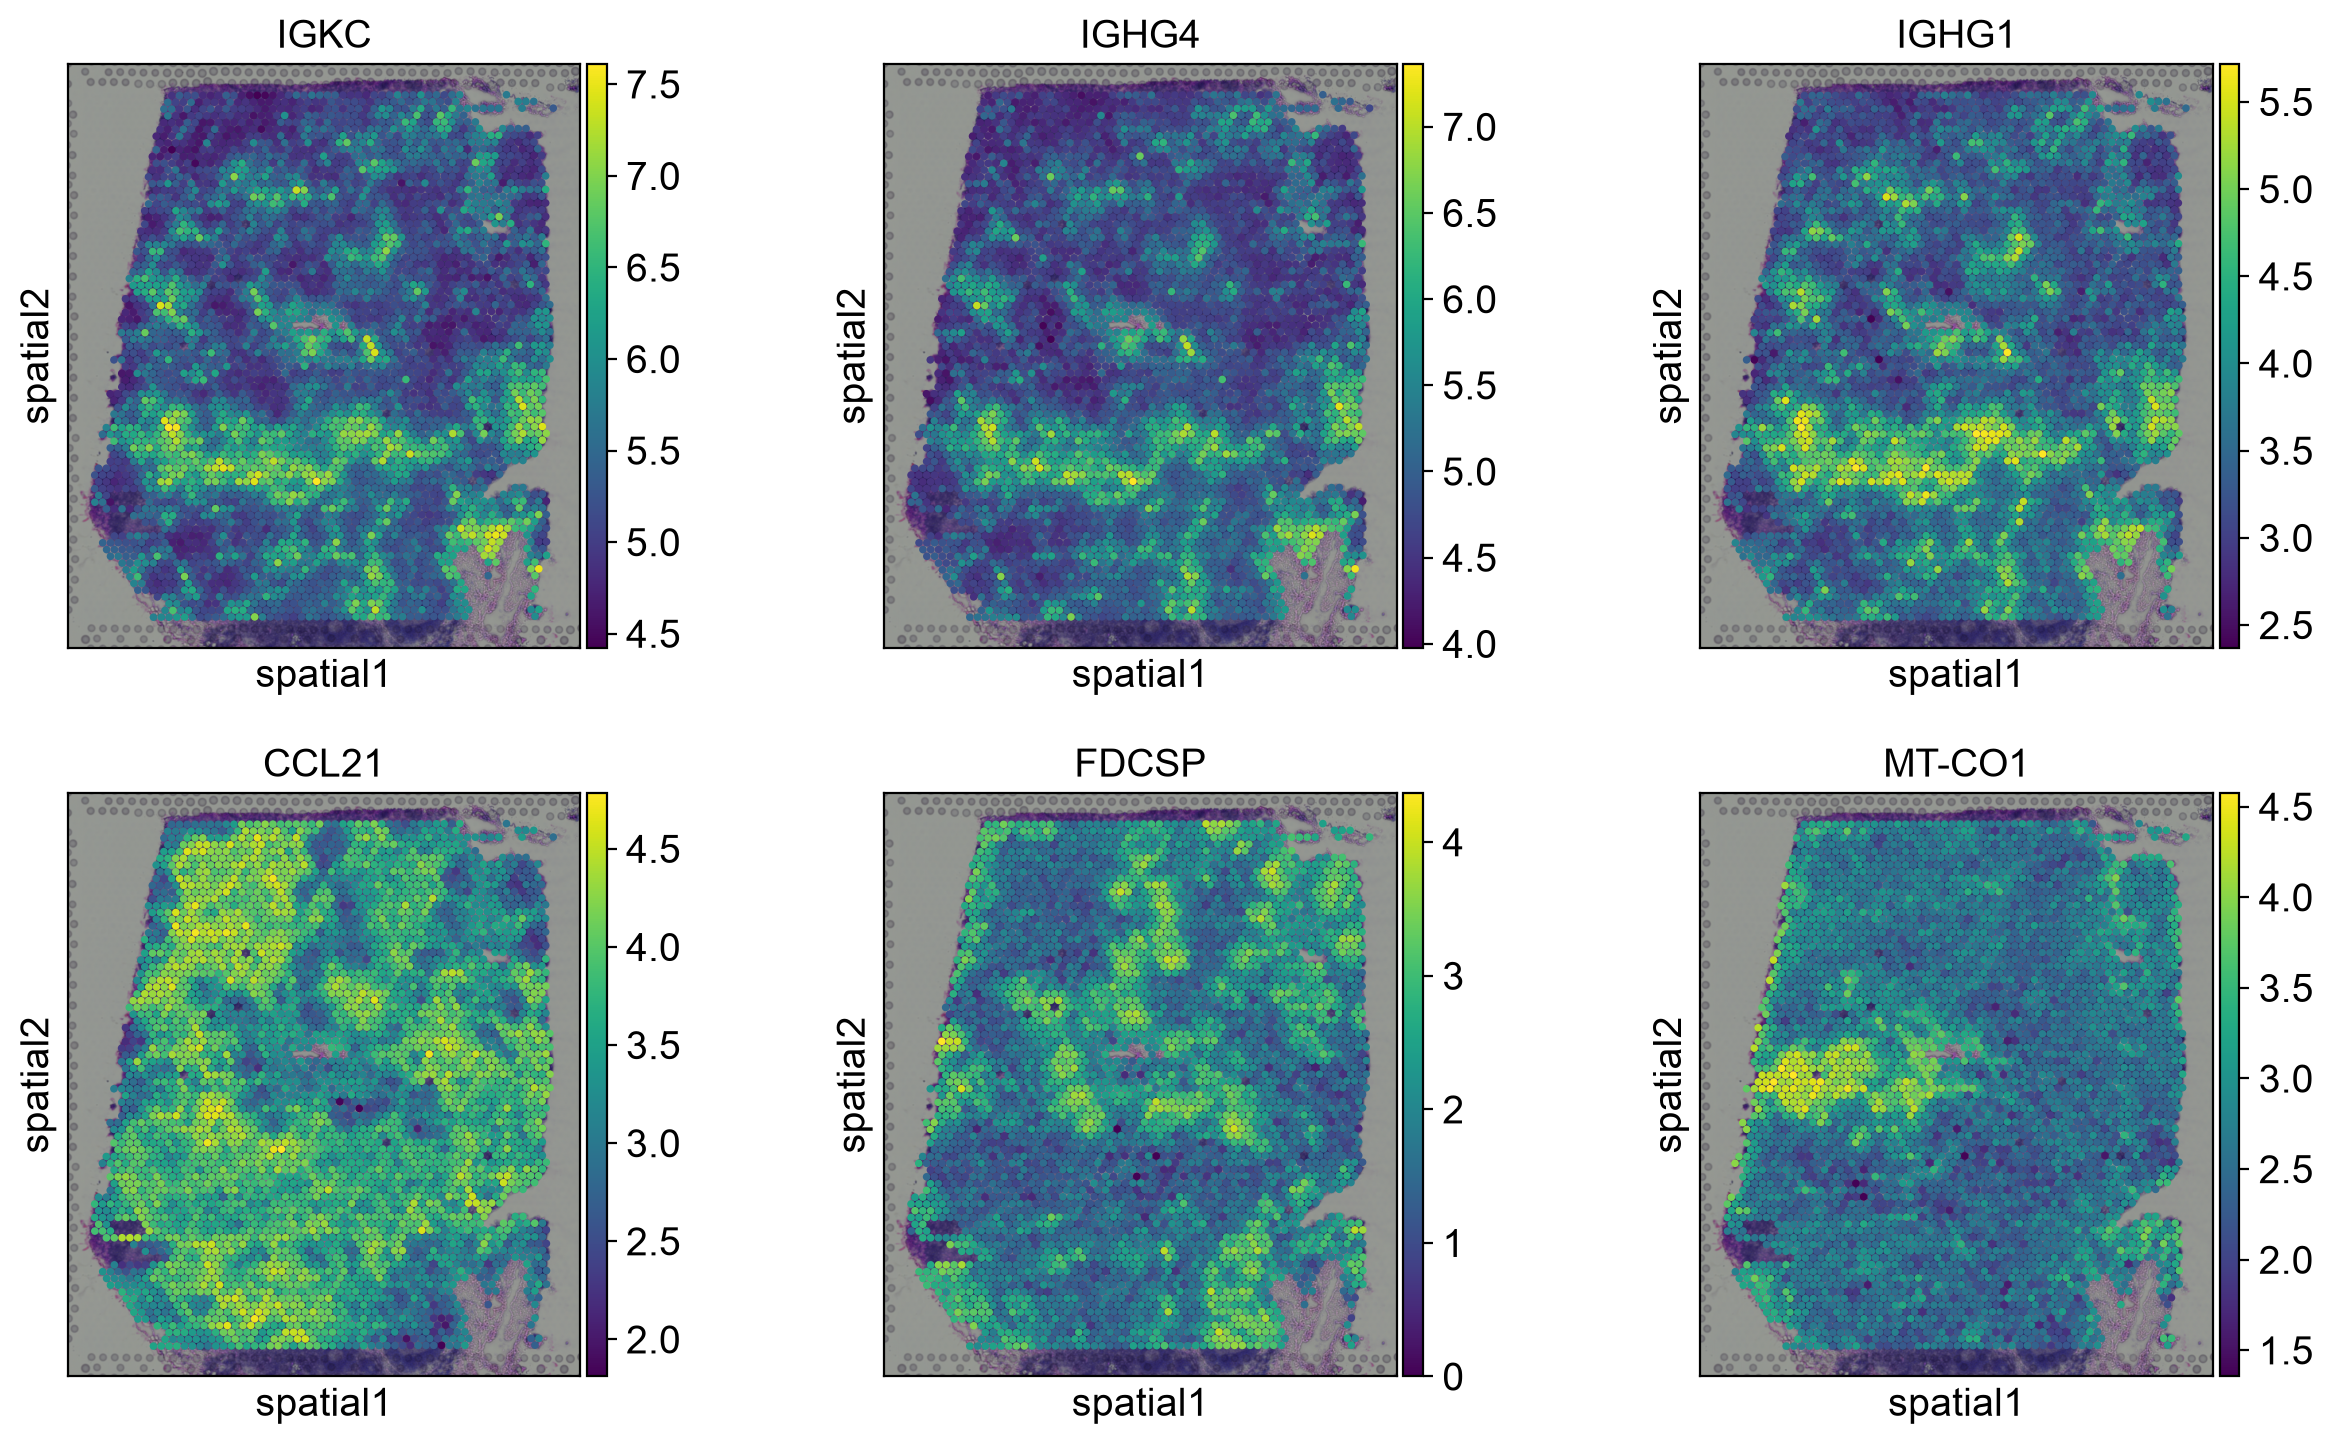

In [25]:
top_genes = adata.uns["moranI"].sort_values("I", ascending=False).head(6).index.tolist()
sc.pl.spatial(adata, color=top_genes, size=1.5, ncols=3)

Just by observing visually, we can see that the top genes for each spatial region do match with the leiden clusters we found earlier. That shows that there are several genes that can indicate structure. We can look deeper and see for which cluster, which gene is most informative by using rank genes groups. 

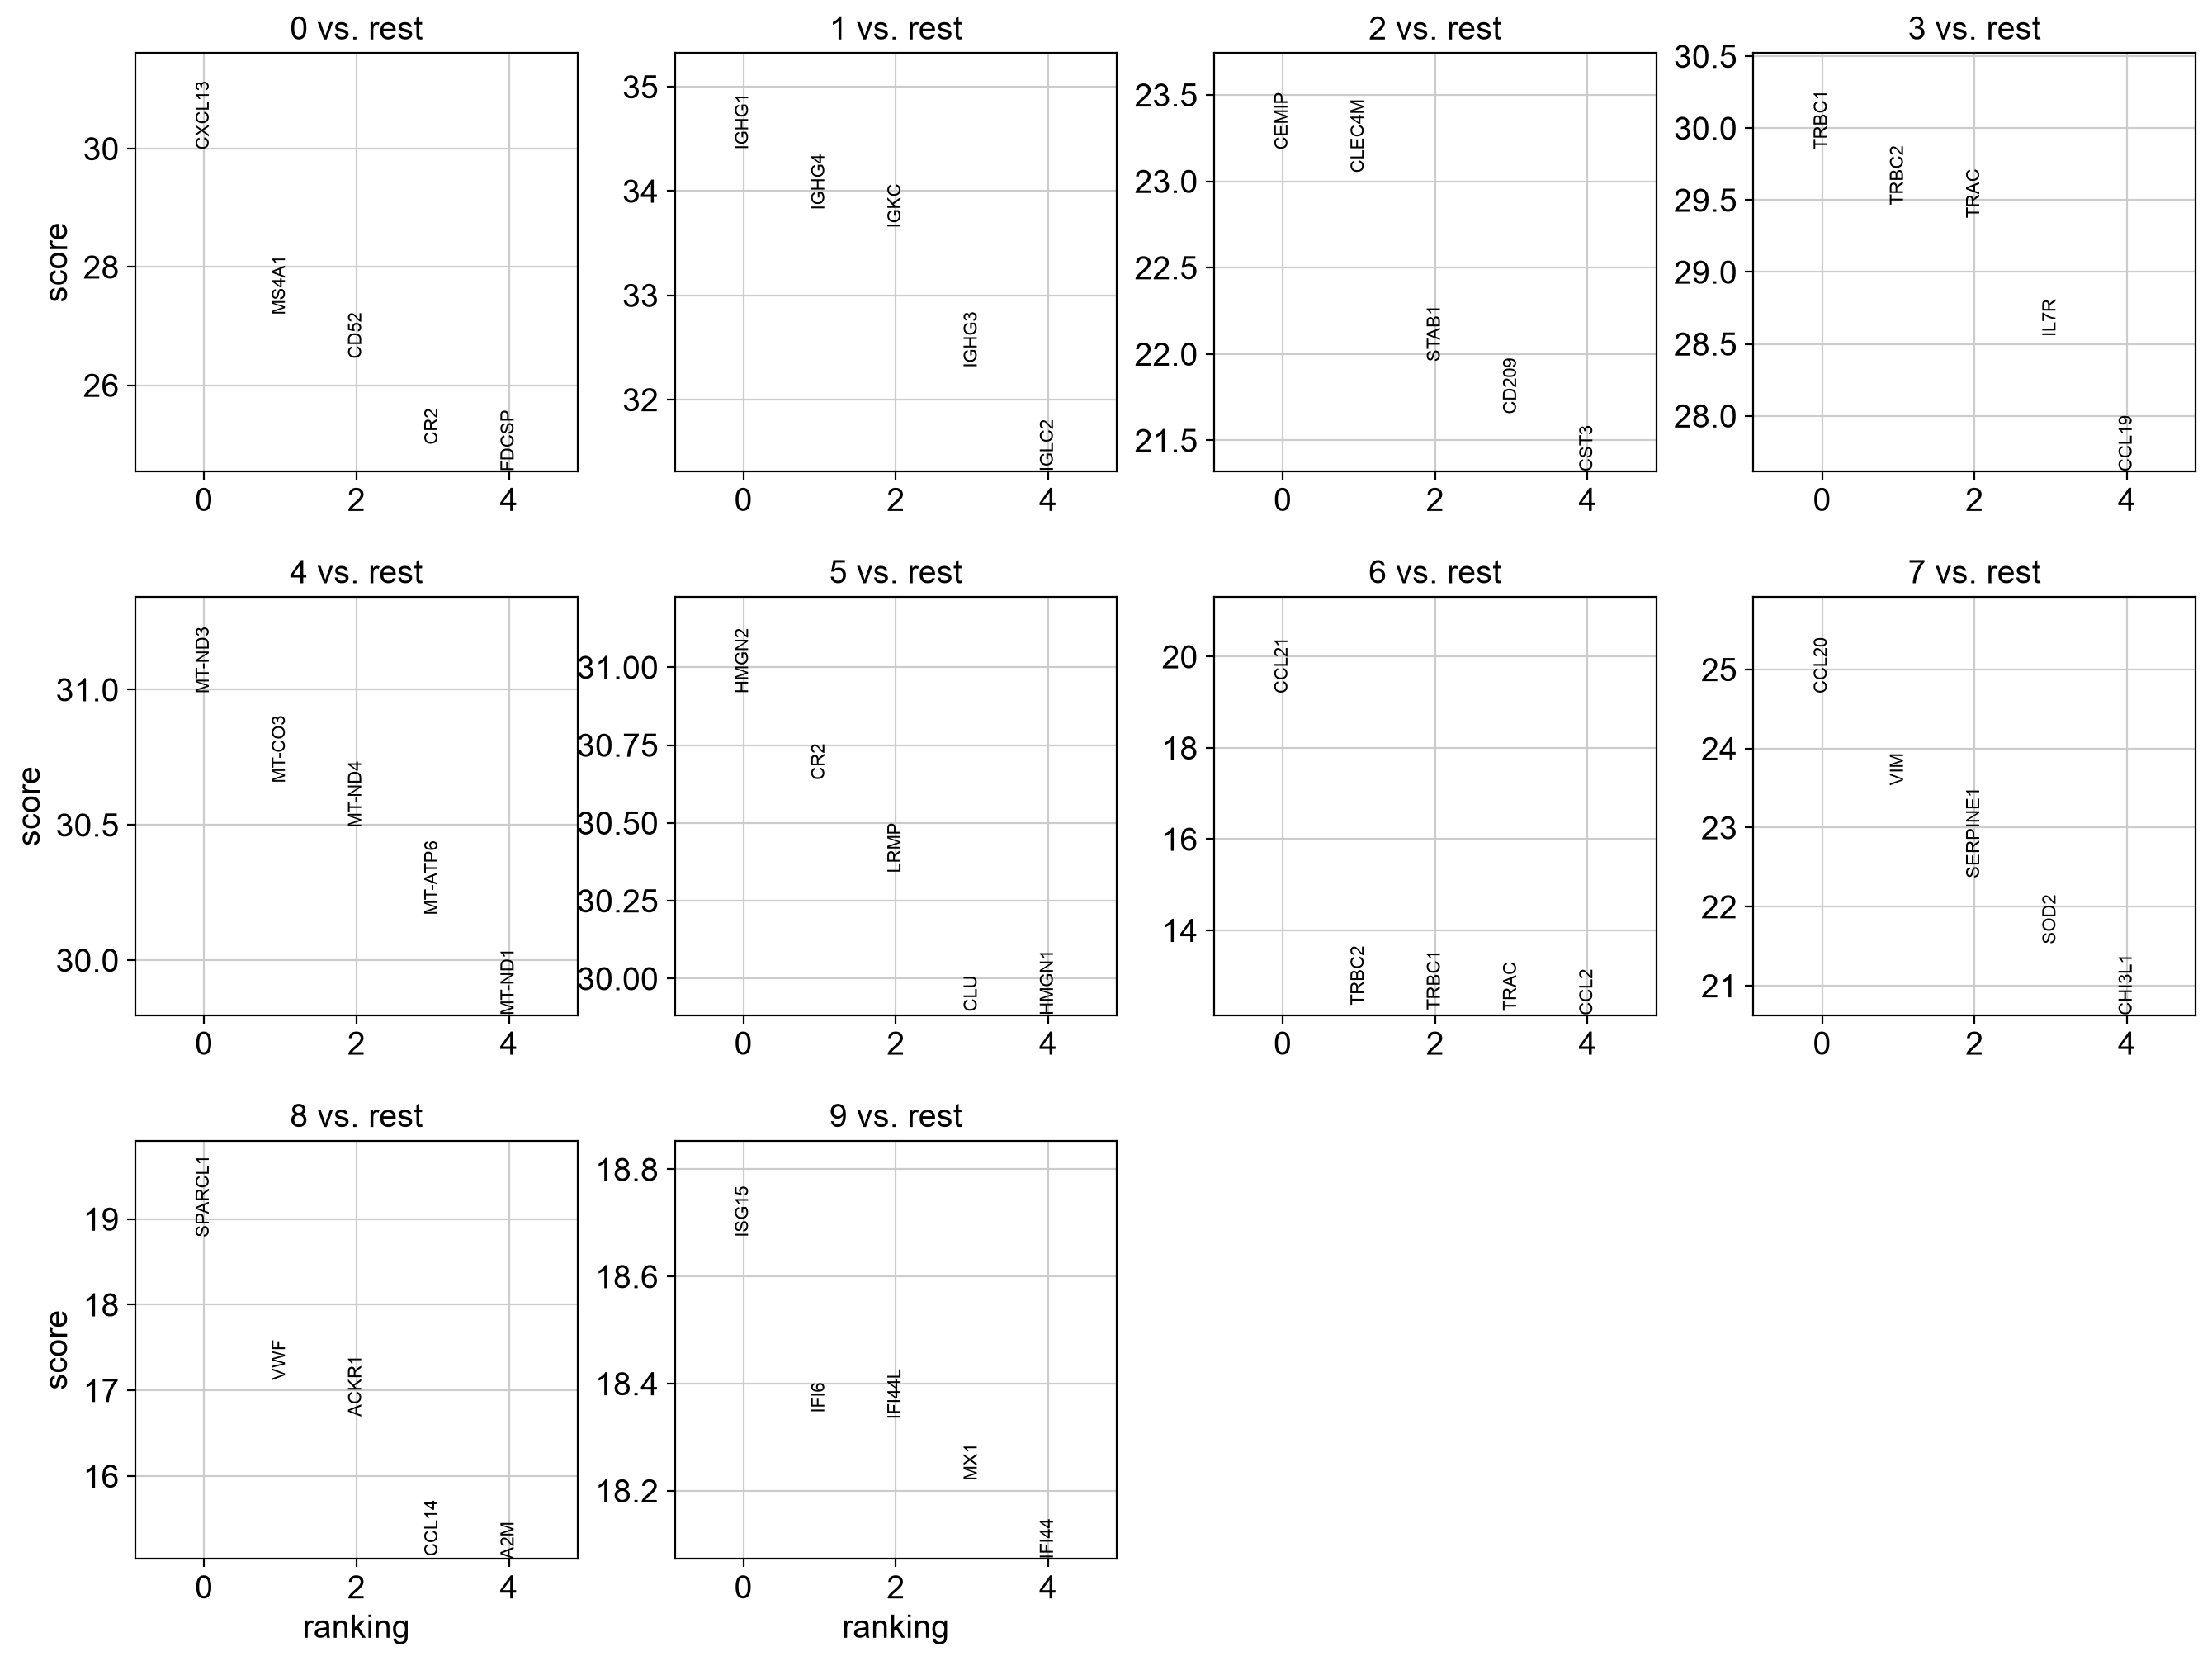

In [26]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

Now we want to know, among the top genes for each cluster, which of those are also spatially informative? So we can find the intersection between the top genes for each cluster and the most spatially variable genes. 

In [27]:
# Get top N genes from each cluster, combined into one set
top_cluster_genes = set()
for cluster in adata.obs['leiden'].cat.categories:
    genes = sc.get.rank_genes_groups_df(adata, group=cluster).head(10)['names'].tolist()
    top_cluster_genes.update(genes)

# Get top N spatially variable genes
top_moran_genes = set(adata.uns["moranI"].sort_values("I", ascending=False).head(50).index.tolist())

# Overlap
overlap = top_cluster_genes & top_moran_genes
print(f"{len(overlap)} genes overlap out of {len(top_cluster_genes)} top cluster genes")
print(overlap)

36 genes overlap out of 91 top cluster genes
{'MT-ND1', 'CXCL13', 'CD22', 'CCL20', 'MT-ND3', 'TRAC', 'MEF2B', 'CR2', 'MT-CO2', 'IGHG2', 'TRBC1', 'MT-CO3', 'MT-ATP6', 'SSR4', 'IFI6', 'RGS13', 'CLU', 'CCL19', 'MT-CYB', 'CCL2', 'HMGB2', 'IGHG1', 'IGHGP', 'CCL21', 'IGHG4', 'FDCSP', 'IFI44L', 'IGLC1', 'MT-CO1', 'IL7R', 'XBP1', 'IGKC', 'MT-ND4', 'MT-ND2', 'HMGN2', 'ISG15'}


We can see that there are 36 genes that are both top cluster genes and spatially informative genes (Moran I). These genes are what we'd be able to use to infer spatial context. 